#THỰC HÀNH: CÁC GIẢI THUẬT PHÂN LOẠI CƠ BẢN

##GIẢI THUẬT 2: SUPPORT VECTOR MACHINE (SVM)
###Bài tập thực hành 2 : Xây dựng mô hình từ giải thuật SVM trên dữ liệu các con thú trong rừng.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


###1.  Nạp dữ liệu

Đọc file CSV vào df và hiển thị vài dòng đầu để khảo sát cấu trúc trường.

Bộ dữ liệu có 871 dòng × 7 cột gồm: AnimalName, symptoms1…symptoms5 (mô tả triệu chứng) và Dangerous (nhãn mục tiêu: “Yes/No”).

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Data_Analysis/DA06/data_animal.csv')
df

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes
...,...,...,...,...,...,...,...
866,Buffaloes,Fever,Difficulty breathing,Poor Appetite,Eye and Skin change,Unable to exercise,Yes
867,Buffaloes,Fever,Loss of appetite,Lession on the skin,Lethargy,Joint Pain,Yes
868,Buffaloes,Lesions in the nasal cavity,Lesions on nose,Vomiting,Noisy Breathing,Lesions on nose,Yes
869,Buffaloes,Hair loss,Dandruff,Vomiting,Crusting of the skin,Ulcerated skin,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptoms4   871 non-null    object
 5   symptoms5   871 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 47.8+ KB


Theo df.info(), các cột hiện đều là kiểu chuỗi (object) ⇒ cần mã hoá trước khi mô hình hoá (vd. one-hot/label encoding).

Dangerous nhiều khả năng là bài toán phân loại nhị phân.

In [ ]:
df.describe()

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
count,871,871,871,871,871,871,869
unique,46,232,230,229,217,203,2
top,Buffaloes,Fever,Diarrhea,Coughing,Weight loss,Pains,Yes
freq,129,257,119,95,117,99,849




###2. Định dạng của đoạn này là mã


Khám phá dữ liệu ban đầu (Descriptive Statistics & Missing Values)

Các hàm cho thấy:

- Dữ liệu gồm 871 mẫu và 7 cột.
- Có 46 loài động vật khác nhau, trong đó Buffaloes xuất hiện nhiều nhất (129 lần).
- Triệu chứng phổ biến nhất là Fever (sốt).
- Cột Dangerous có 2 giá trị: Yes / No, trong đó “Yes” chiếm phần lớn (849/869 mẫu hợp lệ).
- Kết quả df.isna().sum() cho thấy 2 giá trị bị thiếu (NaN) trong cột Dangerous, các cột khác đầy đủ dữ liệu.
- Dòng lệnh lọc df[(df['Dangerous'] != 'Yes') & (df['Dangerous'] != 'No')] xác nhận 2 dòng dữ liệu bị thiếu giá trị nhãn (Dangerous = NaN) — cần được xử lý (ví dụ: loại bỏ hoặc gán nhãn thích hợp).

**Nhận xét:**
Tập dữ liệu tương đối sạch, chỉ có ít giá trị thiếu ở cột mục tiêu. Việc xử lý cẩn thận các giá trị này là cần thiết trước khi xây dựng mô hình phân loại (ví dụ mô hình dự đoán mức độ nguy hiểm của bệnh dựa trên triệu chứng).

In [ ]:
df.isna().sum()

,0
AnimalName,0
symptoms1,0
symptoms2,0
symptoms3,0
symptoms4,0
symptoms5,0
Dangerous,2


In [ ]:
df[(df['Dangerous'] != 'Yes') & (df['Dangerous'] != 'No')]


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
269,Sheep,Teeth griding,Apathy,Dehydration,Ruminal stasis,Watery faeces,NaN
695,Buffaloes,Teeth griding,Apathy,Dehydration,Ruminal stasis,Watery faeces,NaN


In [ ]:
df.dropna(inplace=True)

In [ ]:
df[df.duplicated()]

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
772,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
773,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
774,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
775,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
776,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
777,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
778,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
779,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
780,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
781,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.AnimalName.value_counts()

,count
AnimalName,
Buffaloes,128
Sheep,109
Pig,63
Fowl,62
Elephant,59
Duck,56
Birds,37
cat,36
Dog,34


In [ ]:
df['AnimalName']=df.AnimalName.str.capitalize()

In [ ]:
df.AnimalName.value_counts()

,count
AnimalName,
Buffaloes,128
Sheep,109
Pig,63
Fowl,62
Elephant,59
Duck,57
Birds,37
Cat,36
Donkey,35


In [ ]:
df['AnimalName'].replace({'Black-tailed deer':'Deer','White-tailed deer':'Deer','Mule deer':'Deer','Sika deer':'Deer','Reindeer':'Deer','Elk':'Deer','Wapiti':'Deer','Mules':'Horse','Other birds': 'Birds','Pigs':'Pig', 'Dogs': 'Dog', 'Fox ':'Fox', 'Goats': 'Goat'}, inplace = True)

/tmp/ipython-input-4086457922.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AnimalName'].replace({'Black-tailed deer':'Deer','White-tailed deer':'Deer','Mule deer':'Deer','Sika deer':'Deer','Reindeer':'Deer','Elk':'Deer','Wapiti':'Deer','Mules':'Horse','Other birds': 'Birds','Pigs':'Pig', 'Dogs': 'Dog', 'Fox ':'Fox', 'Goats': 'Goat'}, inplace = True)


In [ ]:
df.AnimalName.value_counts()

,count
AnimalName,
Buffaloes,128
Sheep,109
Pig,66
Fowl,62
Elephant,59
Duck,57
Birds,43
Cat,36
Donkey,35


In [ ]:
def pie(col):
    data_counts =df[col].value_counts()
    plt.pie(data_counts, labels=data_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.set_title(f'Pie plot for {col}')
    plt.show()


In [ ]:
for col in df.columns:
    print(f'Type of {col} column is {df[col].dtype}')


Type of AnimalName column is object
Type of symptoms1 column is object
Type of symptoms2 column is object
Type of symptoms3 column is object
Type of symptoms4 column is object
Type of symptoms5 column is object
Type of Dangerous column is object


###3. Chuẩn hóa tên loài & kiểm tra kiểu dữ liệu

Tiến hành chuẩn hóa các tên loài động vật trong cột AnimalName bằng cách gộp các biến thể cùng nhóm (ví dụ: “Black-tailed deer”, “White-tailed deer”, “Sika deer” → “Deer”).
- Việc này giúp giảm trùng lặp và tăng tính nhất quán của dữ liệu.
- Sau khi chuẩn hóa, lệnh value_counts() cho thấy các loài xuất hiện nhiều nhất là Buffaloes (128), Sheep (109), và Pig (66).
- Định nghĩa hàm pie() để vẽ biểu đồ tròn hiển thị tỷ lệ các giá trị trong từng cột.

Cuối cùng, kiểm tra kiểu dữ liệu cho từng cột (object), cho thấy toàn bộ các cột đều chứa dữ liệu dạng chuỗi phân loại (categorical) — cần mã hóa (encoding) trước khi xây dựng mô hình.

<Axes: xlabel='AnimalName', ylabel='count'>

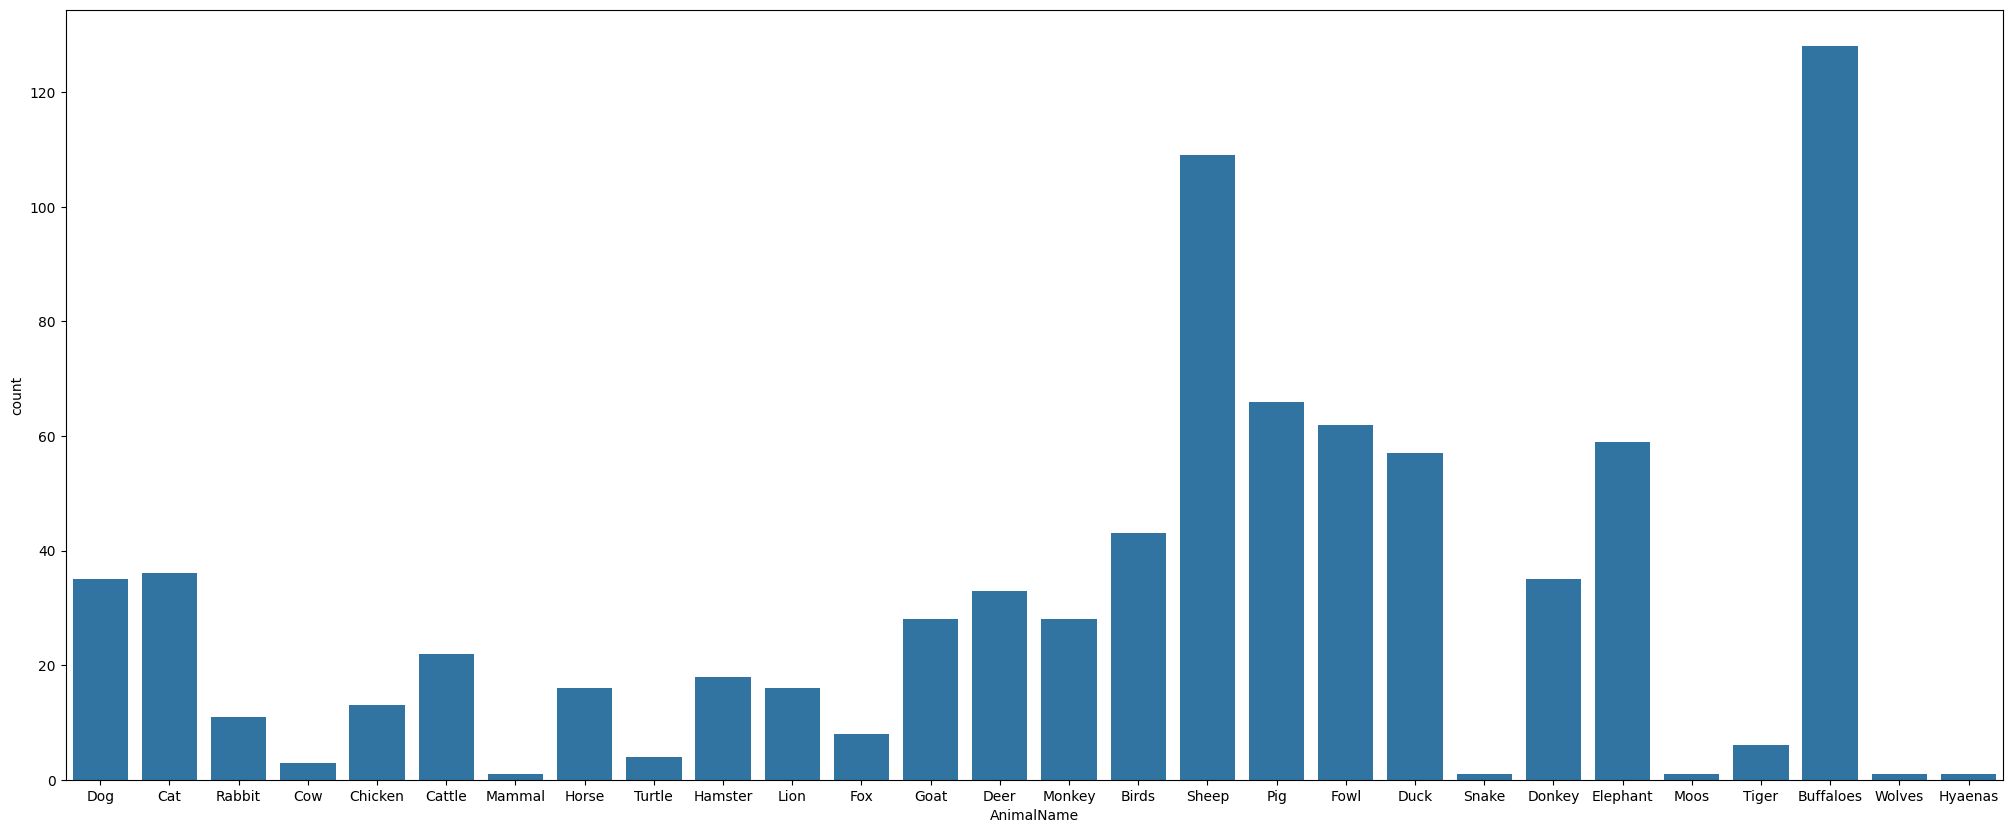

In [ ]:
plt.figure(figsize=(25,10))
sns.countplot(data=df,x=df.AnimalName)

**Nhận xét:** Biểu đồ cột trên thể hiện số lượng mẫu theo từng loài động vật trong tập dữ liệu.
- Buffaloes (Trâu) có số lượng mẫu cao nhất, trên 120 mẫu, chiếm tỷ lệ lớn nhất trong tập dữ liệu.
- Các loài có số lượng mẫu cao tiếp theo là Sheep (Cừu), Pig (Heo), Fowl (Gia cầm) và Elephant (Voi).
- Một số loài có số lượng mẫu rất ít như Mammal, Moos, Hyaenas, Wolves, thể hiện sự mất cân bằng dữ liệu giữa các nhóm.

Kết thúc : Phân bố dữ liệu không đồng đều giữa các loài. Điều này có thể ảnh hưởng đến việc huấn luyện mô hình nếu bài toán cần so sánh hoặc phân loại theo loài. Vì vậy, có thể cần cân nhắc các kỹ thuật xử lý mất cân bằng dữ liệu hoặc chuẩn hóa tỷ lệ mẫu giữa các nhóm trong các bước tiếp theo.

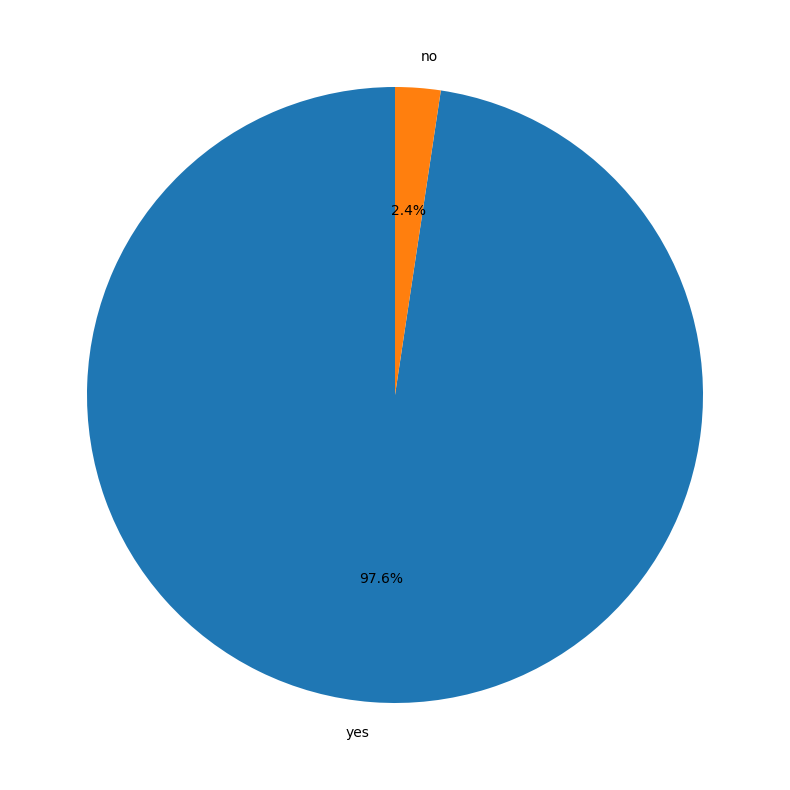

In [ ]:
plt.figure(figsize=(10,10))
plt.pie(df.Dangerous.value_counts(),labels=['yes','no'],autopct='%1.1f%%', startangle=90)
plt.show()

**Nhận xét tổng quan:** Biểu đồ tròn thể hiện tỷ lệ giữa hai nhóm trong cột Dangerous:
- Yes (Nguy hiểm) chiếm 97.6% tổng số mẫu.
- No (Không nguy hiểm) chỉ chiếm 2.4%.
- Dữ liệu bị mất cân bằng nghiêm trọng, với phần lớn mẫu được gán nhãn “Nguy hiểm”.
- Điều này có thể gây thiên lệch (bias) cho mô hình học máy, khiến mô hình dự đoán “Yes” nhiều hơn do đây là lớp chiếm ưu thế.
- Trước khi huấn luyện, cần xử lý mất cân bằng dữ liệu, ví dụ: dùng oversampling (SMOTE) hoặc undersampling để cân bằng hai lớp và cải thiện độ chính xác của mô hình.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
le=LabelEncoder()

In [ ]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,random_state=90)

In [ ]:
model_svm = SVC(kernel = 'linear', random_state = 0)
model_svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [ ]:
y_pred = model_svm.predict(X_test)
print(y_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred)
print(accuracy_svm)

0.976303317535545


In [ ]:
classification_rep_svm = classification_report(y_test, y_pred)
print(classification_rep_svm)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.98      1.00      0.99       206

    accuracy                           0.98       211
   macro avg       0.49      0.50      0.49       211
weighted avg       0.95      0.98      0.96       211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

Accuracy: 0.9715639810426541
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.98      1.00      0.99       206

    accuracy                           0.97       211
   macro avg       0.49      0.50      0.49       211
weighted avg       0.95      0.97      0.96       211



###4. Huấn luyện mô hình SVM và đánh giá kết quả
Trong phần này, quy trình huấn luyện mô hình SVM (Support Vector Machine) được thực hiện nhằm phân loại mức độ nguy hiểm của các trường hợp động vật dựa trên các triệu chứng.

Các bước chính:
- Mã hóa dữ liệu: Các cột kiểu object được mã hóa bằng LabelEncoder, giúp chuyển đổi dữ liệu dạng chữ sang dạng số để mô hình có thể xử lý.
- Tách dữ liệu: Dữ liệu được chia thành tập huấn luyện (train) và tập kiểm tra (test) theo tỉ lệ 75% – 25%.
- Huấn luyện mô hình: Sử dụng mô hình SVC(kernel='linear') – tức là SVM với hàm nhân tuyến tính, giúp tìm siêu phẳng tối ưu để phân chia hai lớp.
- Dự đoán và đánh giá: Dự đoán trên tập kiểm tra cho thấy tất cả các mẫu đều được dự đoán là 1 (nguy hiểm).
- Độ chính xác (accuracy) đạt ~97.6%, tuy nhiên precision, recall và f1-score = 0 cho lớp thiểu số → mô hình bị lệch về lớp đa số.

Kết luận : Mặc dù độ chính xác tổng thể cao, nhưng mô hình không phân biệt được các trường hợp “không nguy hiểm”, do mất cân bằng dữ liệu nghiêm trọng. Cần áp dụng các kỹ thuật cân bằng dữ liệu (như SMOTE hoặc oversampling) trước khi huấn luyện lại để cải thiện hiệu suất phân loại.

#Kết thúc